## Power spectrum around change of mind

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pickle

In [25]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, LFPBandArtifact, ChangeofMindRemoteTheta, ChannelNumber

from spyglass.common import AnalysisNwbfile, LFP
from spyglass.shijiegu.ripple_detection import load_LFP
from spyglass.shijiegu.spectrum import (spectrum_by_animal,
        average_result, get_spectrogram, plot_spectrogram)
import pynwb

In [17]:
list_of_days_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']


In [19]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_spectrogram")

[13:16:27][INFO] Spyglass: Starting {'export_id': 104}
INFO:spyglass:Starting {'export_id': 104}


In [26]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'
success_animal = {}
for animal in ["julio", "klein", "eliot", "lewis", "molly"]:
    all_data = spectrum_by_animal(animal, list_of_days_animals[animal],
                              mode = "change",
                              t_minus = 2, t_plus = 4,
                              window_size = 0.5,  step_size = 0.1)
    # window size determines the resolution of df: here 0.5s -> 2Hz bins


    file_path = f"{output_folder}/spectrum_{animal}_changeofmind.pickle"

    with open(file_path, 'wb') as file:
        pickle.dump(all_data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
        
    success_animal[animal] = 1

[2026-04-27 14:02:15,911][WARNING]: Skipped checksum for file with hash: 5036bcb1-cae5-2abe-3fbe-026ce15c1969, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_H08J1HA9BY.nwb
[2026-04-27 14:02:15,921][WARNING]: Skipped checksum for file with hash: 5036bcb1-cae5-2abe-3fbe-026ce15c1969, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_H08J1HA9BY.nwb


eliot20221018_.nwb


[2026-04-27 14:02:15,948][WARNING]: Skipped checksum for file with hash: 5036bcb1-cae5-2abe-3fbe-026ce15c1969, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_H08J1HA9BY.nwb
[2026-04-27 14:02:15,954][WARNING]: Skipped checksum for file with hash: 5036bcb1-cae5-2abe-3fbe-026ce15c1969, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_H08J1HA9BY.nwb
[2026-04-27 14:02:16,364][WARNING]: Skipped checksum for file with hash: 5036bcb1-cae5-2abe-3fbe-026ce15c1969, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_H08J1HA9BY.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.

eliot20221019_.nwb


[2026-04-27 14:02:22,622][WARNING]: Skipped checksum for file with hash: e4008074-3b74-dc2d-e6cd-bfc335cbc385, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_Q6VIQE364T.nwb
[2026-04-27 14:02:22,634][WARNING]: Skipped checksum for file with hash: e4008074-3b74-dc2d-e6cd-bfc335cbc385, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_Q6VIQE364T.nwb
[2026-04-27 14:02:22,676][WARNING]: Skipped checksum for file with hash: e4008074-3b74-dc2d-e6cd-bfc335cbc385, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_Q6VIQE364T.nwb
[2026-04-27 14:02:22,684][WARNING]: Skipped checksum for file with hash: e4008074-3b74-dc2d-e6cd-bfc335cbc385, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_Q6VIQE364T.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s becaus

...

molly20220418_.nwb


[2026-04-27 14:10:35,568][WARNING]: Skipped checksum for file with hash: 23b3b5aa-fe71-22cb-b1f4-32f228e269f6, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_TUSZ68Z7P1.nwb
[2026-04-27 14:10:35,582][WARNING]: Skipped checksum for file with hash: 23b3b5aa-fe71-22cb-b1f4-32f228e269f6, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_TUSZ68Z7P1.nwb
[2026-04-27 14:10:35,626][WARNING]: Skipped checksum for file with hash: 23b3b5aa-fe71-22cb-b1f4-32f228e269f6, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_TUSZ68Z7P1.nwb
[2026-04-27 14:10:35,635][WARNING]: Skipped checksum for file with hash: 23b3b5aa-fe71-22cb-b1f4-32f228e269f6, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_TUSZ68Z7P1.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because

molly20220419_.nwb


[2026-04-27 14:11:19,061][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
[2026-04-27 14:11:19,071][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
[2026-04-27 14:11:19,110][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
[2026-04-27 14:11:19,117][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
[2026-04-27 14:11:20,094][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/sp

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/spectrum_molly_changeofmind.pickle


In [23]:
#%debug

In [28]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_spectrogram")

### load data and make spectrogram

In [5]:
### exmaples
examples = [('molly20220419_.nwb', "06_Seq2Session3", 50),
            ('julio20230808_.nwb', '08_Seq2Session4', 27)
           ]

In [6]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

all_data_animals = {}
for animal in ["molly","julio"]:
    file_path = f"{output_folder}/spectrum_{animal}_changeofmind.pickle"
    
    with open(file_path, 'rb') as file:
        all_data_animals[animal] = pickle.load(file)
        print(f"Data successfully pickled and saved to {file_path}")

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/spectrum_molly_changeofmind.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/spectrum_julio_changeofmind.pickle


In [9]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2'

for example in examples:
    animal = example[0][:5]
    all_data = all_data_animals[animal]
    
    key = example
    
    taxis = all_data[key]["taxis"]
    center_time = all_data[key]["center_time"]

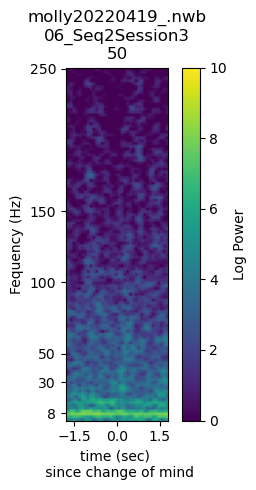

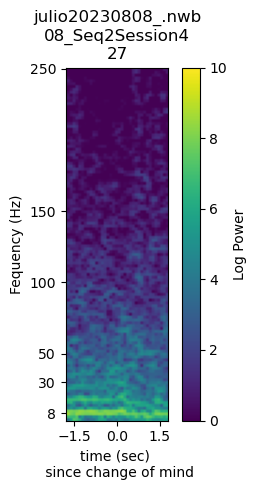

In [13]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2'

for example in examples:
    animal = example[0][:5]
    all_data = all_data_animals[animal]
    
    key = example
    
    taxis = all_data[key]["taxis"]
    center_time = all_data[key]["center_time"]
    faxis = all_data[key]["faxis"]
    Sxx = all_data[key]['Sxx_binned']

    name = f"{example[0]}\n{example[1]}\n{example[2]}"

    plot_spectrogram(taxis, faxis, Sxx, center_time, output_folder = output_folder, name = name)

## End here

In [43]:
fig, axes = plt.subplots(1,2,figsize = (6,5))

for ind in range(2):
    data_ = data[ind]
    ax = axes[ind]

    Sxx_binned = data_["Sxx_binned"]
    bins = data_["bins"]
    center_time = data_["center_time"]
    faxis = data_["faxis"]
    
    ax.imshow(np.log(Sxx_binned),
           extent=[bins[0] - center_time, bins[-1] - center_time, faxis[0], faxis[-1]],
               vmin = 0, vmax = 10, origin='lower',aspect = 0.05)
    
    ax.set_yticks([8,30,50,100,150,250])
    ax.set_ylim([4,250])
    if ind == 0:
        ax.set_xlabel("time (sec) \n since change of mind")
    else:
        ax.set_xlabel("time (sec) \n since outer well poke")
    ax.set_ylabel("Fequency (Hz)")
    ax.set_title("Power Spec")

(76, 19)

In [37]:
len(Sxx)

6384

In [22]:
nwb_copy_file_name = 'molly20220419_.nwb'
session_name = "06_Seq2Session3"

In [24]:
log = pd.DataFrame(
    (ChangeofMindRemoteTheta() & {"nwb_file_name":'molly20220419_.nwb',
                            "epoch":6,"proportion":0.1,
                            "parameter":"params_both_max_all_maze_2_state",
                             "remote_parameter": "dur_0.02_sum_0.2"
                            }).fetch1("pandas"))

In [191]:
log[log.change_of_mind]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,has_remote_interval,remote_interval,remote_content,change_of_mind_num,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
8,1.650396e+09,1.0,1.650396e+09,1.0,2.0,True,True,"[[1650395872.8836162, 1650395872.921616], [165...","[0, 0, 0]","[0, 0, 0]",...,0.0,0.111333,2,2,"[[4, 3, 2, 1]]",1.0,1.0,4.0,3.0,2.0
50,1.650397e+09,1.0,1.650397e+09,4.0,1.0,True,True,"[[1650396864.4872975, 1650396864.5912974], [16...","[0, 0, 0, 0]","[0, 0, 0, 0]",...,0.0,0.000000,1,1,"[[1, 4, -9223372036854775808]]",4.0,4.0,3.0,2.0,1.0
71,1.650397e+09,1.0,1.650397e+09,3.0,2.0,True,True,"[[1650397346.8251424, 1650397346.8551424], [16...","[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",...,0.0,0.000000,2,2,"[[2, 1, 3, -9223372036854775808]]",3.0,3.0,4.0,1.0,1.0


In [155]:
### load LFP

In [222]:
LFP()

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,analysis_file_name name of the file,lfp_object_id the NWB object ID for loading this object from the file,"lfp_sampling_rate the sampling rate, in HZ"
CH61_20211127_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211127_DUYYFQK50S.nwb,ce0774ac-0fb9-4c79-9451-086ff92400c1,1000.0
CH61_20211128_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211128_PFYI3ZK6M2.nwb,a9f64eae-6d63-4091-8b0b-94a373e14a01,1000.0
CH61_20211129_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211129_IAZNQKK900.nwb,a8f28df7-4f3a-4db5-b1c5-5626928fb59a,1000.0
CH61_20211130_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211130_ER86FTW11F.nwb,73168e20-61c4-4aaa-aad8-f00b9e76857f,1000.0
CH61_20211201_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211201_F3TIGTG7E8.nwb,4cc41574-fd6d-4641-a1f9-94514de07e6b,1000.0
CH61_20211202_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211202_THE8NKOPV3.nwb,7f5b79a3-d937-49f2-9ac9-825889b8dc10,1000.0
CH61_20211203_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211203_WJYCHHJKVC.nwb,fbf49870-d540-4da1-8ac4-00110ba0a050,1000.0
CH61_20211204_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211204_1A7NSIUN5L.nwb,c5a3e7ff-988a-4514-ad34-beaf45ed6f81,1000.0
CH61_20211205_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211205_53CZIWTSFQ.nwb,1ea57470-d946-4cbb-9cb8-2d58cbee278b,1000.0
CH61_20211206_.nwb,lfp valid times,LFP 0-400 Hz,30000,CH61_20211206_U9P6SG2XQ1.nwb,1b060545-fefc-40a4-a9b6-7337b6933f35,1000.0


In [223]:
LFP & {'nwb_file_name': nwb_copy_file_name}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,analysis_file_name name of the file,lfp_object_id the NWB object ID for loading this object from the file,"lfp_sampling_rate the sampling rate, in HZ"
molly20220419_.nwb,lfp valid times,LFP 0-400 Hz,30000,molly20220419_DYIFV8Y8E8.nwb,54ff621c-eb64-433b-9261-f6e145d64396,1000.0


### select subset

In [213]:
trialID = 8


(t0,t1) = (log.loc[trialID].initial_time - 2, log.loc[trialID].initial_time + 5)
center_time = log.loc[trialID].initial_time
lfp_data_binned, lfp_time_binned, bins = get_subset_lfp(
    lfp_timestamps, lfp_data, t0, t1)
data1 = {"t0":t0, "t1":t1, "center_time":center_time,
         "lfp_data_binned":lfp_data_binned,
         "lfp_time_binned":lfp_time_binned,
         "bins":bins}

(t0,t1) = (log.loc[trialID].timestamp_O - 2, log.loc[trialID].timestamp_O + 5)
center_time = log.loc[trialID].timestamp_O
lfp_data_binned, lfp_time_binned, bins = get_subset_lfp(
    lfp_timestamps, lfp_data, t0, t1)
data2 = {"t0":t0, "t1":t1, "center_time":center_time,
         "lfp_data_binned":lfp_data_binned,
         "lfp_time_binned":lfp_time_binned,
         "bins":bins}


In [215]:
Sxx_binned1, faxis = get_spectrogram(data1["lfp_time_binned"], data1["lfp_data_binned"])
Sxx_binned2, faxis = get_spectrogram(data2["lfp_time_binned"], data2["lfp_data_binned"])

data1["Sxx_binned"] = Sxx_binned1
data1["faxis"] = faxis
data2["Sxx_binned"] = Sxx_binned2
data2["faxis"] = faxis

data = [data1, data2]

In [217]:
Sxx_binned1

array([[6.99464395e-30, 3.27425529e-30, 5.52101054e-30, ...,
        2.18777328e-30, 9.14739132e-31, 2.86526179e-30],
       [4.38860310e+02, 6.65985669e+02, 4.60746526e+02, ...,
        1.49755405e+02, 6.91070108e+01, 3.23068355e+02],
       [1.58975808e+03, 1.46239655e+03, 3.42636582e+02, ...,
        5.57237718e+01, 4.75046938e+01, 2.66443061e+02],
       ...,
       [5.06216110e-05, 6.32246279e-05, 7.51743903e-05, ...,
        1.16410596e-04, 1.35579834e-04, 9.39370532e-05],
       [4.79620986e-05, 6.14950080e-05, 8.95499858e-05, ...,
        1.59565439e-04, 1.06397730e-04, 9.24188840e-05],
       [4.98279325e-05, 6.47670571e-05, 9.61720852e-05, ...,
        1.27440502e-04, 6.69387374e-05, 7.21650388e-05]])

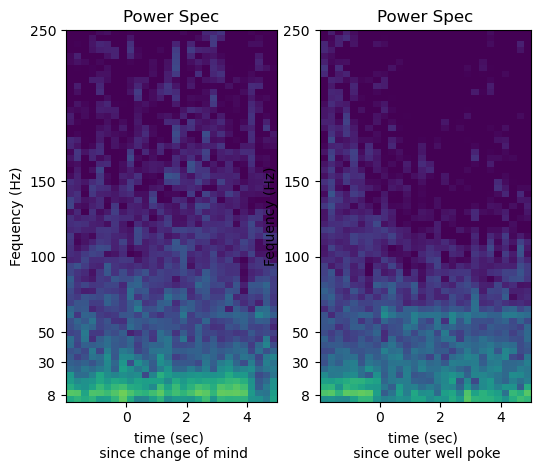

In [216]:
fig, axes = plt.subplots(1,2,figsize = (6,5))

for ind in range(2):
    data_ = data[ind]
    ax = axes[ind]

    Sxx_binned = data_["Sxx_binned"]
    bins = data_["bins"]
    center_time = data_["center_time"]
    faxis = data_["faxis"]
    
    ax.imshow(np.log(Sxx_binned),
           extent=[bins[0] - center_time, bins[-1] - center_time, faxis[0], faxis[-1]],
               vmin = 0, vmax = 10, origin='lower',aspect = 0.05)
    
    ax.set_yticks([8,30,50,100,150,250])
    ax.set_ylim([4,250])
    if ind == 0:
        ax.set_xlabel("time (sec) \n since change of mind")
    else:
        ax.set_xlabel("time (sec) \n since outer well poke")
    ax.set_ylabel("Fequency (Hz)")
    ax.set_title("Power Spec")